In [2]:
pip install meteostat

***papaya growth recommendation system by fetching weather data of 6 months from meteostat***

***fetch temperature,precipitation,windspeed and wind direction from meteostat and save it in w_data***

In [3]:
import pandas as pd
from meteostat import Point, Daily
from datetime import datetime

# Define cities with their coordinates
city_coordinates = {
    "Karachi": (24.8607, 67.0011),
    "Hyderabad": (25.3969, 68.3774),
    "Badin": (24.6553, 68.8321),
    "Multan": (30.1575, 71.5249),
    "Bahawalpur": (29.3956, 71.6724),
    "Muzaffargarh": (30.0756, 71.1924),
    "Lodhran": (29.5402, 71.6331),
    "Gwadar": (25.1216, 62.3254),
    "Panjgur": (26.9645, 64.0918),
    "Dera Ismail Khan": (31.8281, 70.898)
}

# Define start and end dates
start_date = datetime(2023, 11, 25)
end_date = datetime(2024, 5, 25)

# Initialize an empty list to store city data
weather_data = []

# Fetch weather data for each city and append to the list
for city, (lat, lon) in city_coordinates.items():
    # Define location for the city
    location = Point(lat, lon)

    # Fetch daily weather data
    data = Daily(location, start=start_date, end=end_date)
    data = data.fetch()

    # Append data to the list
    city_data = pd.DataFrame({
        'City': city,
        'Date': data.index,
        'Average Temperature': data['tavg'],
        'Total Precipitation': data['prcp'],
        'Average Wind Speed': data['wspd'],
        'Wind Direction': data['wdir']
    })
    weather_data.append(city_data)

# Concatenate all city data into a single DataFrame
weather_data = pd.concat(weather_data, ignore_index=True)

# Save data to CSV file
weather_data.to_csv('w_data.csv', index=False)


# ***calculate drought index and frost and then apply if else condition to recommend papaya growth and save these three features along woth previus four in w_data1***

In [4]:
import pandas as pd

# Load weather data from CSV file
weather_data = pd.read_csv('w_data.csv')



# Calculate Frost Index (Assuming a temperature threshold)
frost_threshold = 2  # Temperature threshold below which frost occurs
weather_data['Frost'] = weather_data['Average Temperature'] < frost_threshold

# Calculate Drought Index (Assuming a basic threshold)
drought_threshold = 101  # Adjust as needed
weather_data['Drought Index'] = 100 - ((weather_data['Total Precipitation'] / 2) * 10)  # Adjust as needed

# Provide Recommendations based on specified conditions
weather_data['Recommendation'] = (
    (weather_data['Average Temperature'] > 26) &
    (weather_data['Average Temperature'] < 35) &
    (~weather_data['Frost']) &
    (weather_data['Average Wind Speed'] <= 25) &
    (weather_data['Drought Index'] < drought_threshold)
)
weather_data['Recommendation'] = weather_data['Recommendation'].map({True: 'Grow papaya', False: 'Do not grow papaya'})

# Save updated data to CSV file
weather_data.to_csv('w_data1.csv', index=False)


# ***KNN algorithm***

Number of rows and columns: (1830, 9)
First few rows:       City        Date  Average Temperature  Total Precipitation  \
0  Karachi  2023-11-25                 26.2                  0.0   
1  Karachi  2023-11-26                 22.1                  4.8   
2  Karachi  2023-11-27                 20.4                  0.0   
3  Karachi  2023-11-28                 20.4                  0.0   
4  Karachi  2023-11-29                 20.4                  0.0   

   Average Wind Speed  Wind Direction  Frost  Drought Index  \
0                27.7            52.0  False          100.0   
1                24.1            43.0  False           76.0   
2                17.3            22.0  False          100.0   
3                16.2            36.0  False          100.0   
4                14.3            23.0  False          100.0   

       Recommendation  
0  Do not grow papaya  
1  Do not grow papaya  
2  Do not grow papaya  
3  Do not grow papaya  
4  Do not grow papaya  
Column names: 

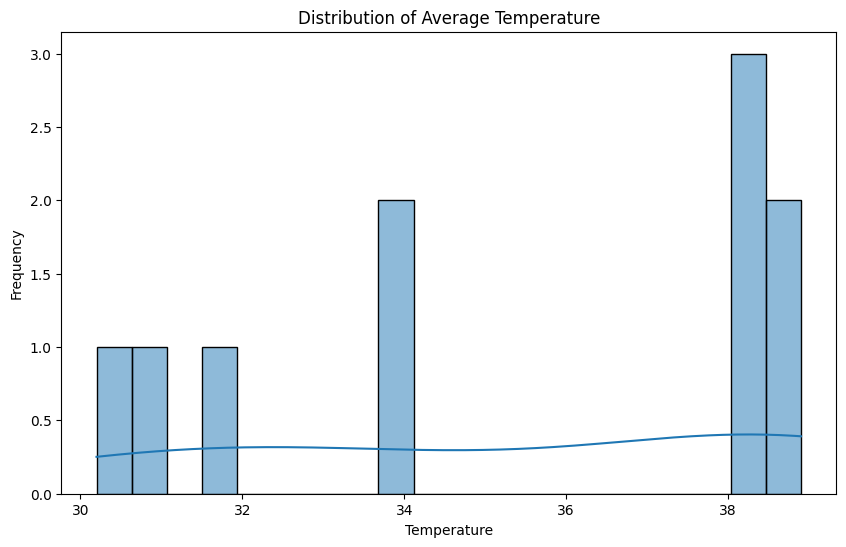

Boxplot


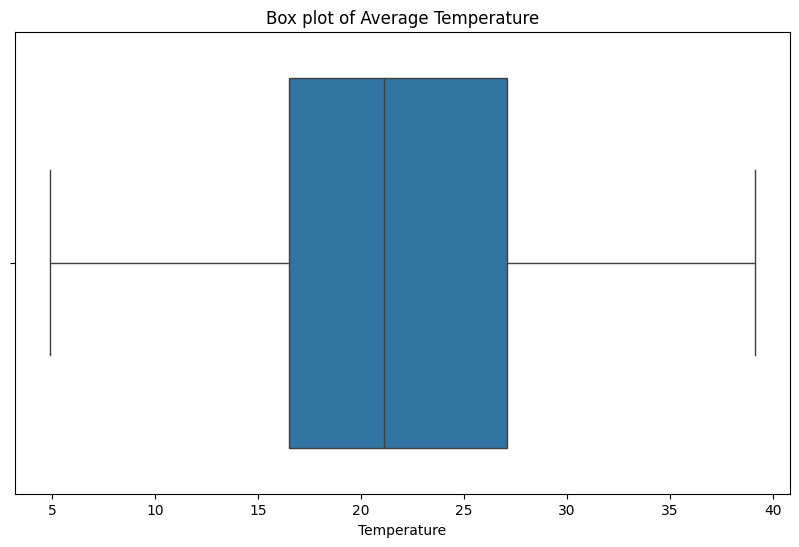

Outliers detected using Z-score method:
Empty DataFrame
Columns: [City, Date, Average Temperature, Total Precipitation, Average Wind Speed, Wind Direction, Frost, Drought Index, Recommendation, z_score]
Index: []
City: Karachi
Average Temperature: 31.0
Total Precipitation: 0.0
Average Wind Speed: 22.9
Frost: False
Drought Index: 100.0
Recommendation: Grow papaya

City: Hyderabad
Average Temperature: 33.8
Total Precipitation: 0.0
Average Wind Speed: 24.2
Frost: False
Drought Index: 100.0
Recommendation: Grow papaya

City: Badin
Average Temperature: 34.0
Total Precipitation: 0.0
Average Wind Speed: 18.1
Frost: False
Drought Index: 100.0
Recommendation: Grow papaya

City: Multan
Average Temperature: 38.9
Total Precipitation: 0.0
Average Wind Speed: 18.6
Frost: False
Drought Index: 100.0
Recommendation: Do not grow papaya

City: Bahawalpur
Average Temperature: 38.3
Total Precipitation: 0.0
Average Wind Speed: 16.4
Frost: False
Drought Index: 100.0
Recommendation: Grow papaya

City: Muzaffa

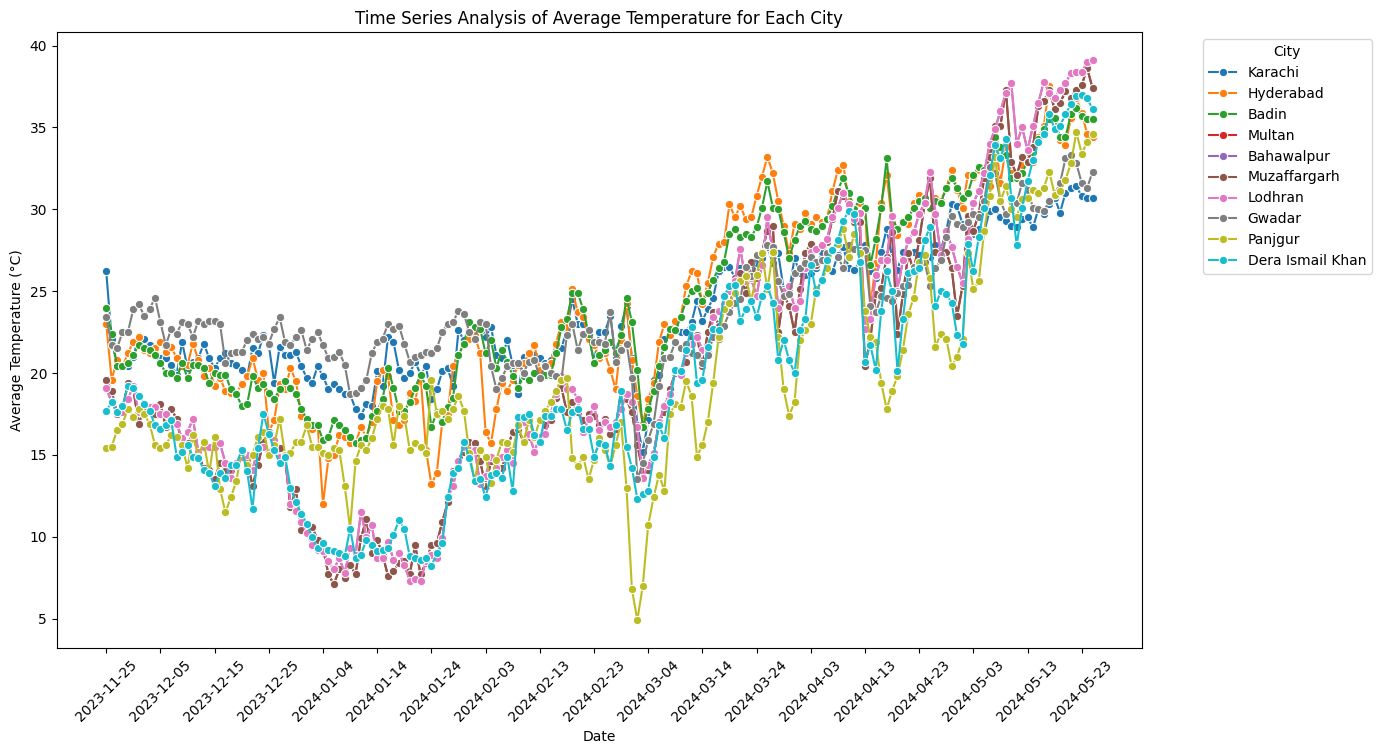

Bar Graph


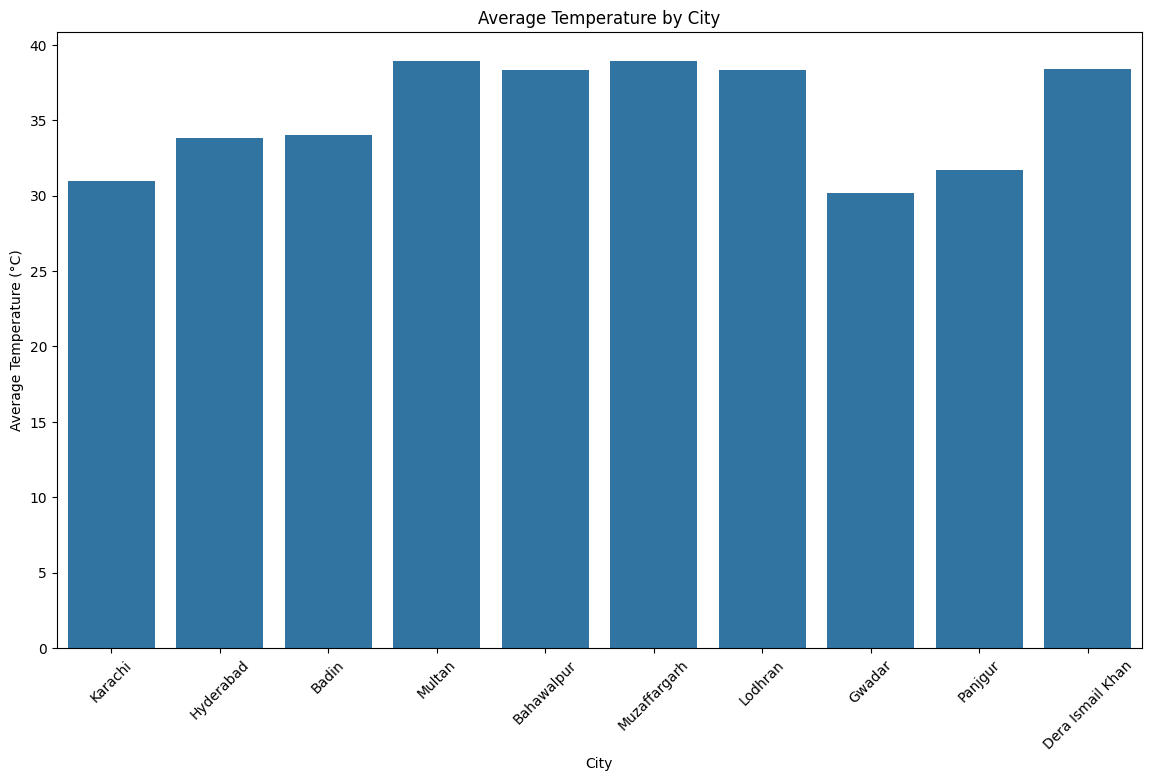

Correlation Heatmap


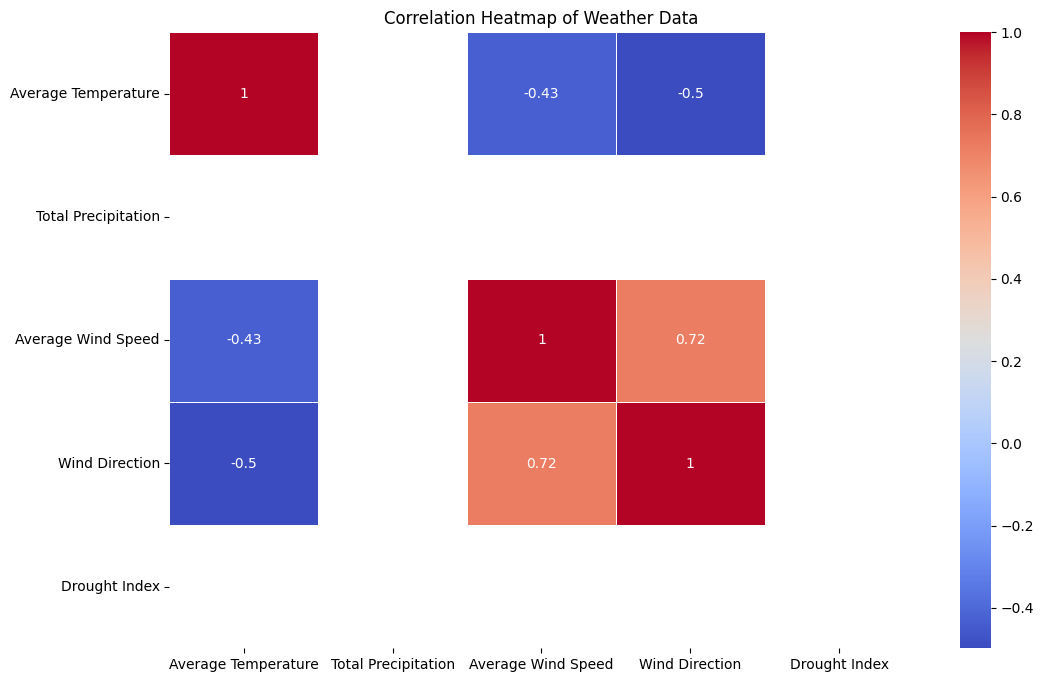

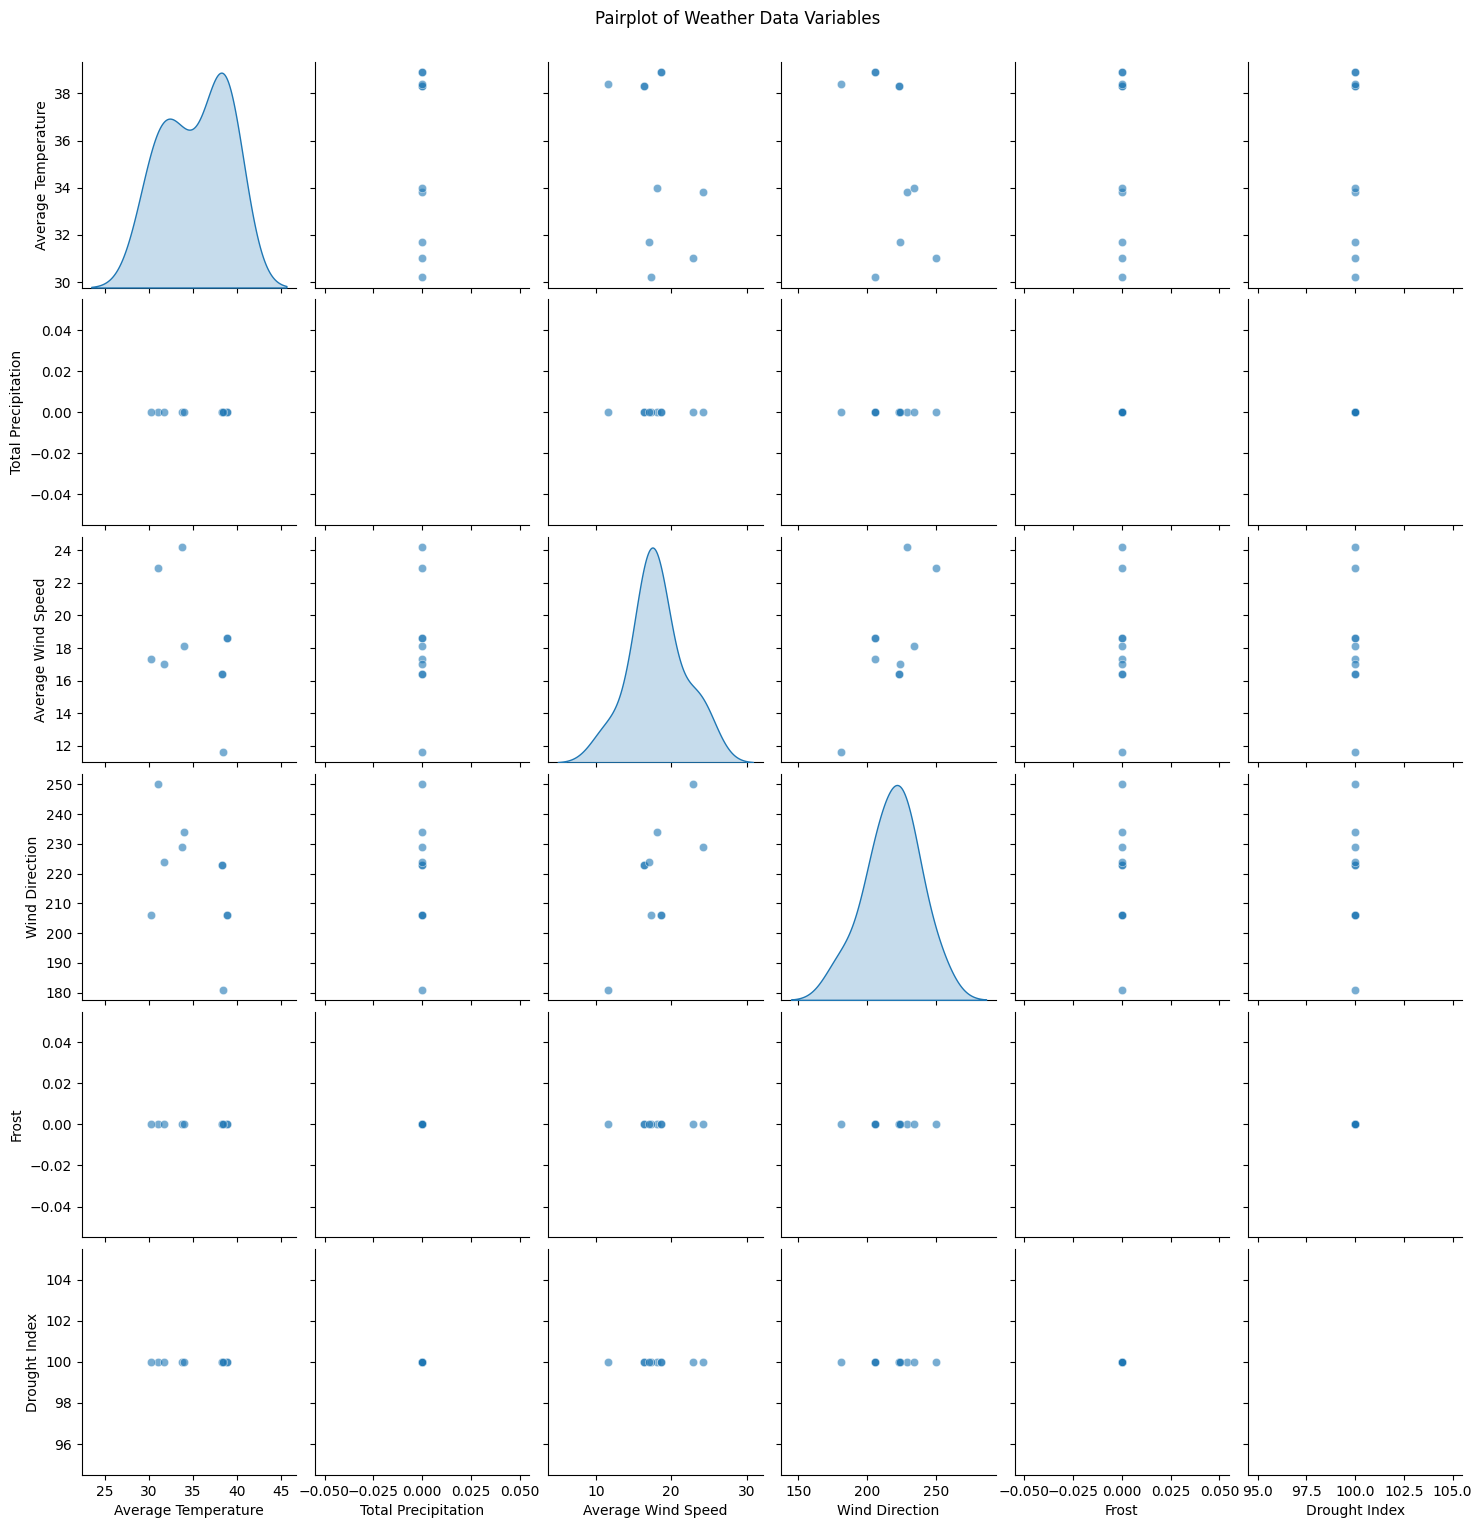

Confusion Matrix:
[[1341   53]
 [  31  405]]


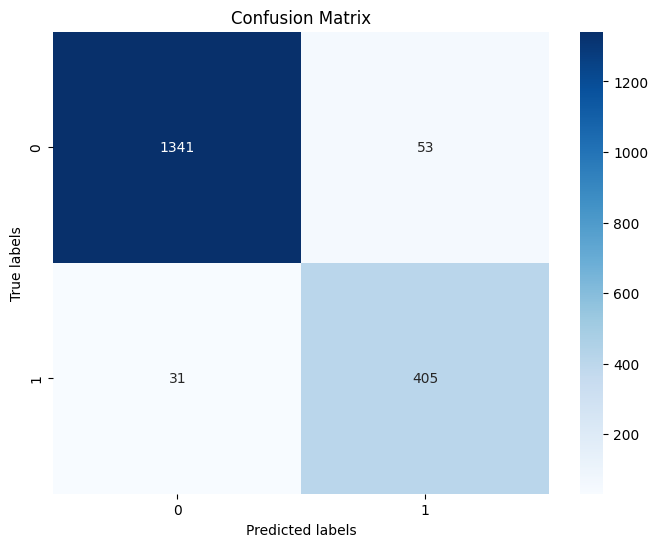

In [5]:
from meteostat import Point, Daily
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy.stats import zscore
from sklearn.neighbors import KNeighborsClassifier

# Define cities with their coordinates
city_coordinates = {
    "Karachi": (24.8607, 67.0011),
    "Hyderabad": (25.3969, 68.3774),
    "Badin": (24.6553, 68.8321),
    "Multan": (30.1575, 71.5249),
    "Bahawalpur": (29.3956, 71.6724),
    "Muzaffargarh": (30.0756, 71.1924),
    "Lodhran": (29.5402, 71.6331),
    "Gwadar": (25.1216, 62.3254),
    "Panjgur": (26.9645, 64.0918),
    "Dera Ismail Khan": (31.8281, 70.898),
}

# Get today's date
today = datetime.today().date()

# Format the date
formatted_date = today.strftime("%Y,%m,%d")
# Split the formatted date and convert to integers
year, month, day = map(int, formatted_date.split(','))

# Define start and end dates
start_date = datetime(year, month, day)
end_date = datetime(year, month, day)

# Initialize an empty list to store city data
weather_data = []

# Fetch weather data for each city and append to the list
for city, (lat, lon) in city_coordinates.items():
    # Define location for the city
    location = Point(lat, lon)

    # Fetch daily weather data
    data = Daily(location, start=start_date, end=end_date)
    data = data.fetch()

    # Calculate Frost Index (Assuming a temperature threshold)
    frost_threshold = 2  # Temperature threshold below which frost occurs
    frost = data['tavg'].mean() < frost_threshold

    # Calculate Drought Index (Assuming a basic threshold)
    drought_threshold = 101  # Adjust as needed
    drought_index = 100 - ((data['prcp'].sum() / 2) * 10)  # Adjust as needed

    # Append data to the list
    city_data = {
        'City': city,
        'Average Temperature': data['tavg'].mean(),
        'Total Precipitation': data['prcp'].sum(),
        'Average Wind Speed': data['wspd'].mean(),
        'Wind Direction': data['wdir'].mean(),
        'Frost': frost,
        'Drought Index': drought_index
    }
    weather_data.append(city_data)

# Convert weather_data to DataFrame
weather_df = pd.DataFrame(weather_data)

# Load historical weather data with indices
weather_data_with_indices = pd.read_csv('w_data1.csv')

# 1. Data Exploration
# Check the number of rows and columns
print("Number of rows and columns:", weather_data_with_indices.shape)
# Print the first few rows and check basic statistics of weather_df
print("First few rows:", weather_data_with_indices.head())
# Column names
print("Column names:", weather_data_with_indices.columns)

# 2. Data Cleaning
print("Data has been cleaned")

# 5. Data Visualization
print("Data visualization")
plt.figure(figsize=(10, 6))
sns.histplot(weather_df['Average Temperature'], bins=20, kde=True)
plt.title('Distribution of Average Temperature')
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.show()

# Box plot
print("Boxplot")
plt.figure(figsize=(10, 6))
sns.boxplot(x=weather_data_with_indices['Average Temperature'])
plt.title('Box plot of Average Temperature')
plt.xlabel('Temperature')
plt.show()

# Z-score method
# Compute the Z-score for the column of interest
weather_data_with_indices['z_score'] = zscore(weather_data_with_indices['Average Temperature'])

# Define a threshold for outlier detection (e.g., 3 standard deviations)
threshold = 3

# Identify outliers based on the Z-score
outliers = weather_data_with_indices[(weather_data_with_indices['z_score'] > threshold) | (weather_data_with_indices['z_score'] < -threshold)]

# Print the outliers
print("Outliers detected using Z-score method:")
print(outliers)

# Remove the z_score column if it's no longer needed
weather_data_with_indices.drop(columns=['z_score'], inplace=True)

# Train KNN model
X_train = weather_data_with_indices[['Average Temperature', 'Total Precipitation', 'Average Wind Speed', 'Wind Direction', 'Frost', 'Drought Index']]
y_train = weather_data_with_indices['Recommendation']

# Impute missing values in X_train
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)

# Fit KNN model
knn = KNeighborsClassifier()
knn.fit(X_train_imputed, y_train)

# Predict recommendation for each city
predictions = knn.predict(X_train_imputed)

# Print predictions for each city in weather_df
for index, city_data in weather_df.iterrows():
    print("City:", city_data['City'])
    print("Average Temperature:", city_data['Average Temperature'])
    print("Total Precipitation:", city_data['Total Precipitation'])
    print("Average Wind Speed:", city_data['Average Wind Speed'])
    print("Frost:", city_data['Frost'])
    print("Drought Index:", city_data['Drought Index'])

    # Predict recommendation for the city
    X_city = [city_data['Average Temperature'],
              city_data['Total Precipitation'],
              city_data['Average Wind Speed'],
              city_data['Wind Direction'],
              city_data['Frost'],
              city_data['Drought Index']]
    recommendation = knn.predict([X_city])[0]

    print("Recommendation:", recommendation)
    print()

# Evaluate model accuracy
accuracy = accuracy_score(y_train, predictions)
precision = precision_score(y_train, predictions, average='weighted')
recall = recall_score(y_train, predictions, average='weighted')
f1 = f1_score(y_train, predictions, average='weighted')

# Print evaluation metrics
print("Model Accuracy:", accuracy)
print("Model Precision:", precision)
print("Model Recall:", recall)
print("Model F1-Score:", f1)

weather_data_with_indices['Date'] = pd.to_datetime(weather_data_with_indices['Date'])

# Plot the time series analysis graph
print("Time series analysis graph")
plt.figure(figsize=(14, 8))
sns.lineplot(data=weather_data_with_indices, x='Date', y='Average Temperature', hue='City', marker='o')
plt.title('Time Series Analysis of Average Temperature for Each City')
plt.xlabel('Date')
plt.ylabel('Average Temperature (°C)')
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')

# Customize x-axis to show dates with a 10-day interval
date_range = pd.date_range(start=weather_data_with_indices['Date'].min(),
                           end=weather_data_with_indices['Date'].max(),
                           freq='10D')
plt.xticks(date_range, rotation=45)

plt.show()

# Bar Graph
print("Bar Graph")
plt.figure(figsize=(14, 8))
sns.barplot(data=weather_df, x='City', y='Average Temperature')
plt.title('Average Temperature by City')
plt.xlabel('City')
plt.ylabel('Average Temperature (°C)')
plt.xticks(rotation=45)
plt.show()

# Correlation Heatmap
print("Correlation Heatmap")
# Select only numeric columns for the correlation matrix
numeric_columns = weather_df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = weather_df[numeric_columns].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Weather Data')
plt.show()
sns.pairplot(weather_df, diag_kind='kde', markers='o', plot_kws={'alpha': 0.6})

# Add titles and labels to the pairplot
plt.suptitle('Pairplot of Weather Data Variables', y=1.02)
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_train, predictions)
print("Confusion Matrix:")
print(conf_matrix)
# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()


# ***random forest algorithm***

Number of rows and columns: (1830, 9)
First few rows:       City        Date  Average Temperature  Total Precipitation  \
0  Karachi  2023-11-25                 26.2                  0.0   
1  Karachi  2023-11-26                 22.1                  4.8   
2  Karachi  2023-11-27                 20.4                  0.0   
3  Karachi  2023-11-28                 20.4                  0.0   
4  Karachi  2023-11-29                 20.4                  0.0   

   Average Wind Speed  Wind Direction  Frost  Drought Index  \
0                27.7            52.0  False          100.0   
1                24.1            43.0  False           76.0   
2                17.3            22.0  False          100.0   
3                16.2            36.0  False          100.0   
4                14.3            23.0  False          100.0   

       Recommendation  
0  Do not grow papaya  
1  Do not grow papaya  
2  Do not grow papaya  
3  Do not grow papaya  
4  Do not grow papaya  
Column names: 

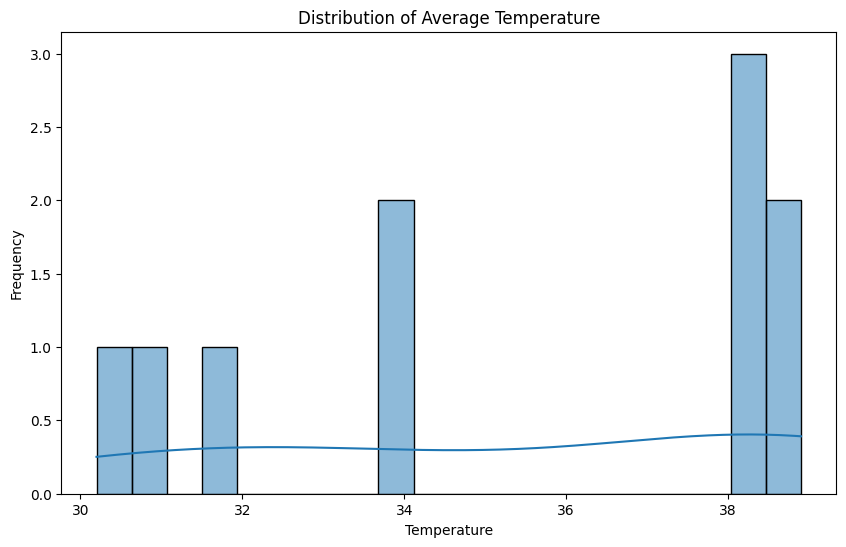

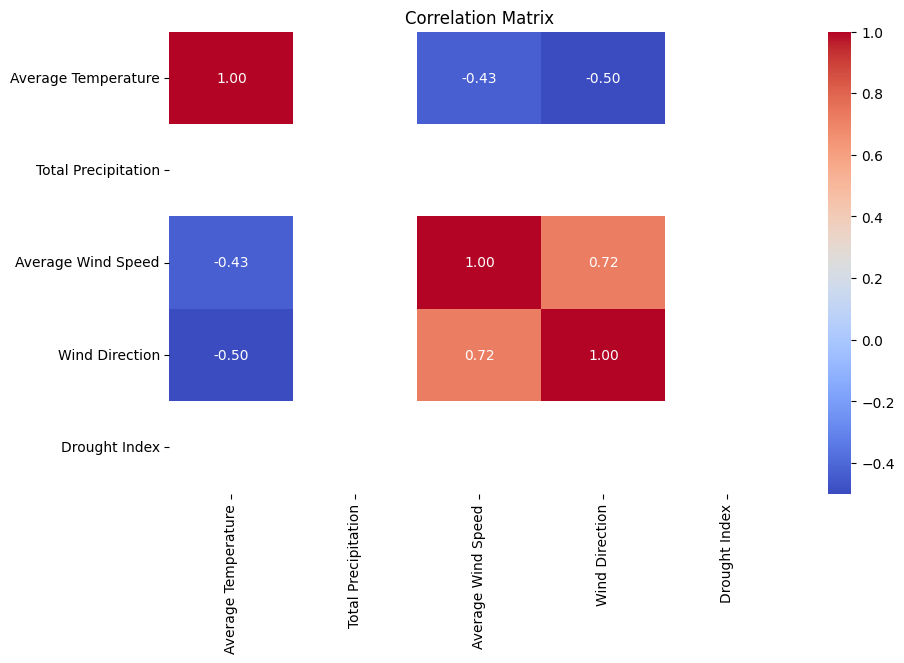

Boxplot


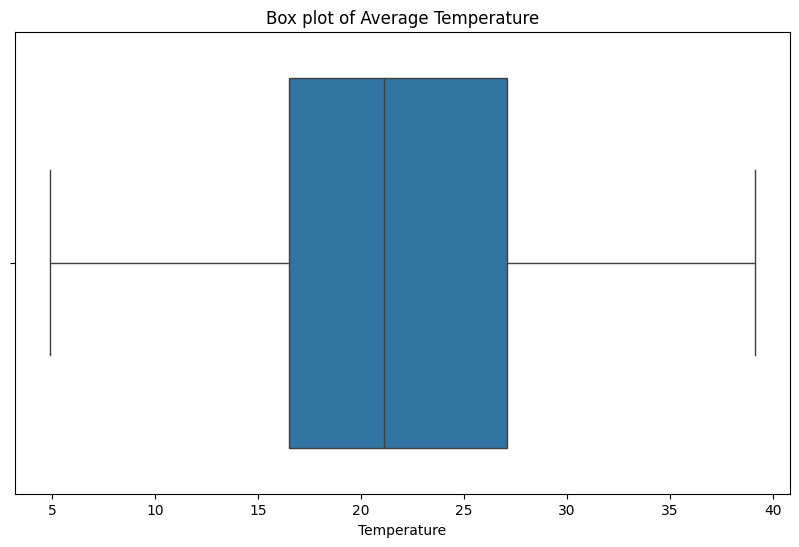

Outliers detected using Z-score method:
Empty DataFrame
Columns: [City, Date, Average Temperature, Total Precipitation, Average Wind Speed, Wind Direction, Frost, Drought Index, Recommendation, z_score]
Index: []
City: Karachi
Average Temperature: 31.0
Total Precipitation: 0.0
Average Wind Speed: 22.9
Frost: False
Drought Index: 100.0
Recommendation: Grow papaya

City: Hyderabad
Average Temperature: 33.8
Total Precipitation: 0.0
Average Wind Speed: 24.2
Frost: False
Drought Index: 100.0
Recommendation: Grow papaya

City: Badin
Average Temperature: 34.0
Total Precipitation: 0.0
Average Wind Speed: 18.1
Frost: False
Drought Index: 100.0
Recommendation: Grow papaya

City: Multan
Average Temperature: 38.9
Total Precipitation: 0.0
Average Wind Speed: 18.6
Frost: False
Drought Index: 100.0
Recommendation: Do not grow papaya

City: Bahawalpur
Average Temperature: 38.3
Total Precipitation: 0.0
Average Wind Speed: 16.4
Frost: False
Drought Index: 100.0
Recommendation: Do not grow papaya

City: 

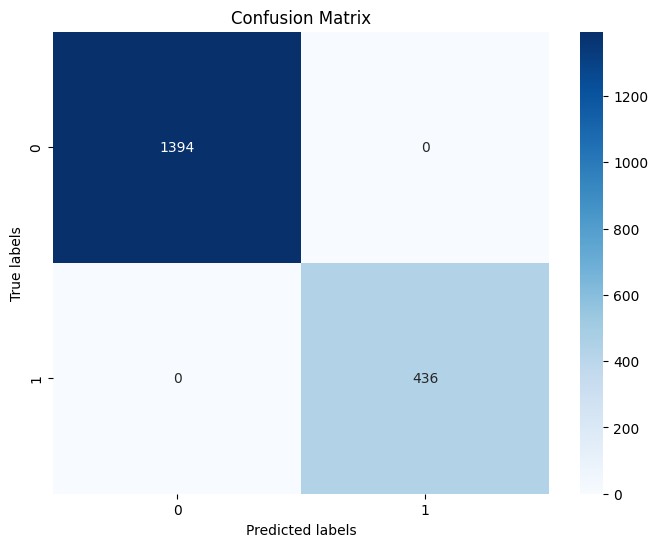

In [6]:
from meteostat import Point, Daily
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from scipy.stats import zscore

# Define cities with their coordinates
city_coordinates = {
    "Karachi": (24.8607, 67.0011),
    "Hyderabad": (25.3969, 68.3774),
    "Badin": (24.6553, 68.8321),
    "Multan": (30.1575, 71.5249),
    "Bahawalpur": (29.3956, 71.6724),
    "Muzaffargarh": (30.0756, 71.1924),
    "Lodhran": (29.5402, 71.6331),
    "Gwadar": (25.1216, 62.3254),
    "Panjgur": (26.9645, 64.0918),
    "Dera Ismail Khan": (31.8281, 70.898),
}

# Get today's date
today = datetime.today().date()

# Format the date
formatted_date = today.strftime("%Y,%m,%d")
# Split the formatted date and convert to integers
year, month, day = map(int, formatted_date.split(','))

# Define start and end dates
start_date = datetime(year, month, day)
end_date = datetime(year, month, day)

# Initialize an empty list to store city data
weather_data = []

# Fetch weather data for each city and append to the list
for city, (lat, lon) in city_coordinates.items():
    # Define location for the city
    location = Point(lat, lon)

    # Fetch daily weather data
    data = Daily(location, start=start_date, end=end_date)
    data = data.fetch()

    # Calculate Frost Index (Assuming a temperature threshold)
    frost_threshold = 2  # Temperature threshold below which frost occurs
    frost = data['tavg'].mean() < frost_threshold

    # Calculate Drought Index (Assuming a basic threshold)
    drought_threshold = 101  # Adjust as needed
    drought_index = 100 - ((data['prcp'].sum() / 2) * 10)  # Adjust as needed

    # Append data to the list
    city_data = {
        'City': city,
        'Average Temperature': data['tavg'].mean(),
        'Total Precipitation': data['prcp'].sum(),
        'Average Wind Speed': data['wspd'].mean(),
        'Wind Direction': data['wdir'].mean(),
        'Frost': frost,
        'Drought Index': drought_index
    }
    weather_data.append(city_data)

# Convert weather_data to DataFrame
weather_df = pd.DataFrame(weather_data)

# Load historical weather data with indices
weather_data_with_indices = pd.read_csv('w_data1.csv')

# 1. Data Exploration
# Check the number of rows and columns
print("Number of rows and columns:", weather_data_with_indices.shape)
# Print the first few rows and check basic statistics of weather_df
print("First few rows:", weather_data_with_indices.head())
# Column names
print("Column names:", weather_data_with_indices.columns)

# 2. Data Cleaning
print("Data has been cleaned")

# 5. Data Visualization
print("Data visualization")
plt.figure(figsize=(10, 6))
sns.histplot(weather_df['Average Temperature'], bins=20, kde=True)
plt.title('Distribution of Average Temperature')
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.show()

# Example: Visualize correlations
plt.figure(figsize=(10, 6))

# Select only numeric columns for correlation calculation
numeric_cols = weather_df.select_dtypes(include=['float64', 'int64']).columns

# Compute correlation matrix for numeric columns only
correlation_matrix = weather_df[numeric_cols].corr()

# Plot the correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# Box plot
print("Boxplot")
plt.figure(figsize=(10, 6))
sns.boxplot(x=weather_data_with_indices['Average Temperature'])
plt.title('Box plot of Average Temperature')
plt.xlabel('Temperature')
plt.show()

# Z-score method
# Compute the Z-score for the column of interest
weather_data_with_indices['z_score'] = zscore(weather_data_with_indices['Average Temperature'])

# Define a threshold for outlier detection (e.g., 3 standard deviations)
threshold = 3

# Identify outliers based on the Z-score
outliers = weather_data_with_indices[(weather_data_with_indices['z_score'] > threshold) | (weather_data_with_indices['z_score'] < -threshold)]

# Print the outliers
print("Outliers detected using Z-score method:")
print(outliers)

# Remove the z_score column if it's no longer needed
weather_data_with_indices.drop(columns=['z_score'], inplace=True)

# Train machine learning model
X_train = weather_data_with_indices[['Average Temperature', 'Total Precipitation', 'Average Wind Speed', 'Wind Direction', 'Frost', 'Drought Index']]
y_train = weather_data_with_indices['Recommendation']

# Impute missing values in X_train
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)

model = RandomForestClassifier()
model.fit(X_train_imputed, y_train)

# Predict recommendation for each city
predictions = model.predict(X_train_imputed)

# Print predictions for each city in weather_df
for index, city_data in weather_df.iterrows():
    print("City:", city_data['City'])
    print("Average Temperature:", city_data['Average Temperature'])
    print("Total Precipitation:", city_data['Total Precipitation'])
    print("Average Wind Speed:", city_data['Average Wind Speed'])
    print("Frost:", city_data['Frost'])
    print("Drought Index:", city_data['Drought Index'])

    # Predict recommendation for the city
    X_city = [city_data['Average Temperature'],
              city_data['Total Precipitation'],
              city_data['Average Wind Speed'],
              city_data['Wind Direction'],
              city_data['Frost'],
              city_data['Drought Index']]
    recommendation = model.predict([X_city])[0]

    print("Recommendation:", recommendation)
    print()

# Evaluate model accuracy
accuracy = accuracy_score(y_train, predictions)
precision = precision_score(y_train, predictions, average='weighted')
recall = recall_score(y_train, predictions, average='weighted')
f1 = f1_score(y_train, predictions, average='weighted')

# Print evaluation metrics
print("Model Accuracy:", accuracy)
print("Model Precision:", precision)
print("Model Recall:", recall)
print("Model F1-Score:", f1)

# Calculate and print the confusion matrix
conf_matrix = confusion_matrix(y_train, predictions)
print("Confusion Matrix:")
print(conf_matrix)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

# ***support vector machine***

Number of rows and columns: (1830, 9)
First few rows:       City        Date  Average Temperature  Total Precipitation  \
0  Karachi  2023-11-25                 26.2                  0.0   
1  Karachi  2023-11-26                 22.1                  4.8   
2  Karachi  2023-11-27                 20.4                  0.0   
3  Karachi  2023-11-28                 20.4                  0.0   
4  Karachi  2023-11-29                 20.4                  0.0   

   Average Wind Speed  Wind Direction  Frost  Drought Index  \
0                27.7            52.0  False          100.0   
1                24.1            43.0  False           76.0   
2                17.3            22.0  False          100.0   
3                16.2            36.0  False          100.0   
4                14.3            23.0  False          100.0   

       Recommendation  
0  Do not grow papaya  
1  Do not grow papaya  
2  Do not grow papaya  
3  Do not grow papaya  
4  Do not grow papaya  
Column names: 

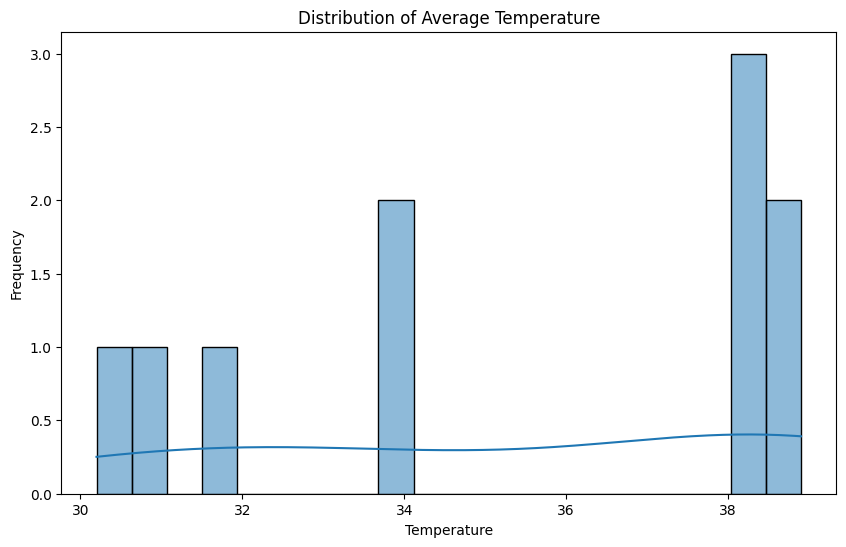

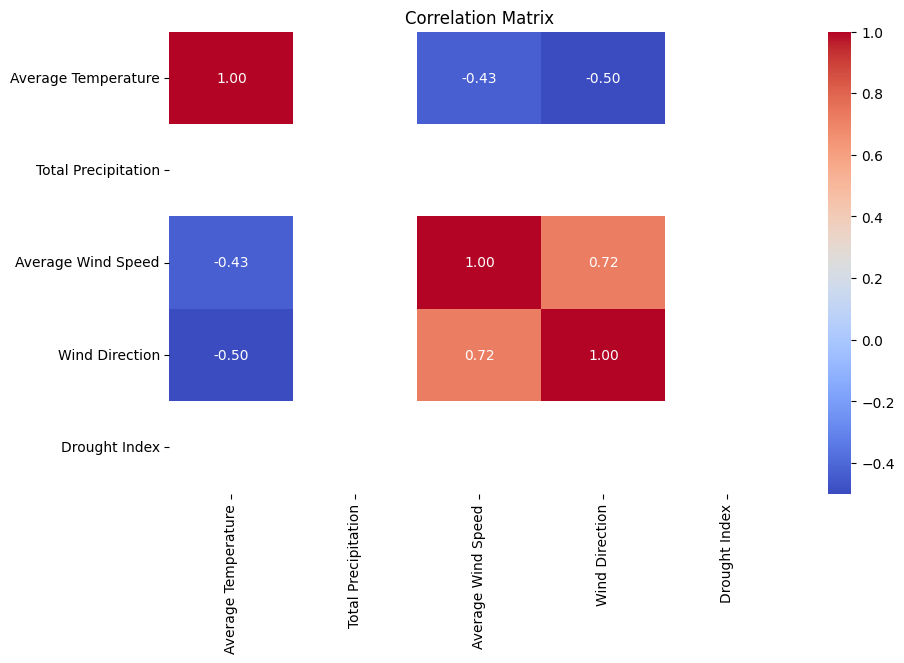

Boxplot


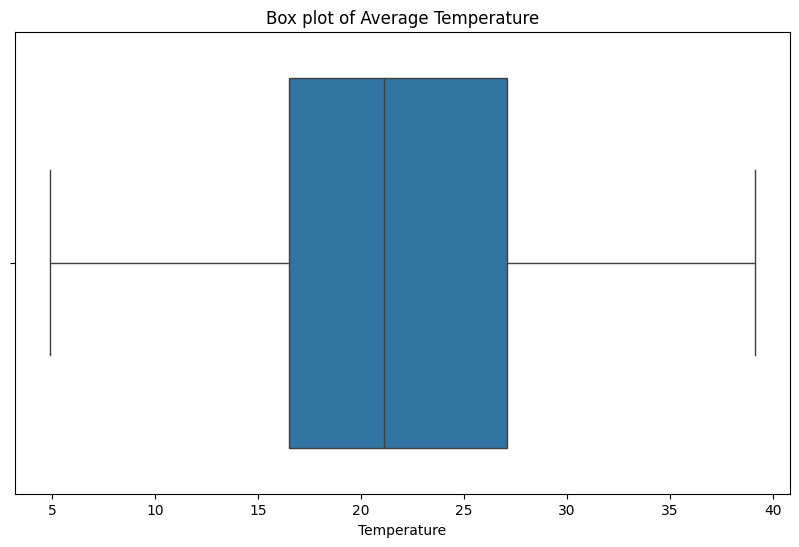

Outliers detected using Z-score method:
Empty DataFrame
Columns: [City, Date, Average Temperature, Total Precipitation, Average Wind Speed, Wind Direction, Frost, Drought Index, Recommendation, z_score]
Index: []
City: Karachi
Average Temperature: 31.0
Total Precipitation: 0.0
Average Wind Speed: 22.9
Frost: False
Drought Index: 100.0
Recommendation: Grow papaya

City: Hyderabad
Average Temperature: 33.8
Total Precipitation: 0.0
Average Wind Speed: 24.2
Frost: False
Drought Index: 100.0
Recommendation: Grow papaya

City: Badin
Average Temperature: 34.0
Total Precipitation: 0.0
Average Wind Speed: 18.1
Frost: False
Drought Index: 100.0
Recommendation: Grow papaya

City: Multan
Average Temperature: 38.9
Total Precipitation: 0.0
Average Wind Speed: 18.6
Frost: False
Drought Index: 100.0
Recommendation: Grow papaya

City: Bahawalpur
Average Temperature: 38.3
Total Precipitation: 0.0
Average Wind Speed: 16.4
Frost: False
Drought Index: 100.0
Recommendation: Grow papaya

City: Muzaffargarh
A

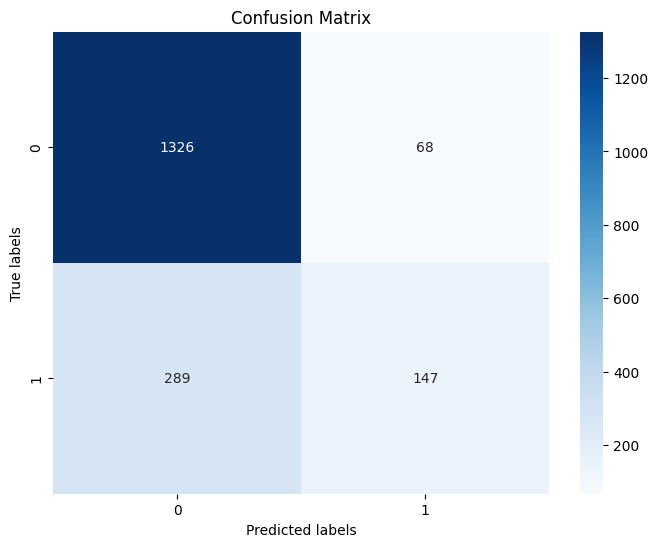

Confusion Matrix:
[[1326   68]
 [ 289  147]]


In [7]:
from meteostat import Point, Daily
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy.stats import zscore

# Define cities with their coordinates
city_coordinates = {
    "Karachi": (24.8607, 67.0011),
    "Hyderabad": (25.3969, 68.3774),
    "Badin": (24.6553, 68.8321),
    "Multan": (30.1575, 71.5249),
    "Bahawalpur": (29.3956, 71.6724),
    "Muzaffargarh": (30.0756, 71.1924),
    "Lodhran": (29.5402, 71.6331),
    "Gwadar": (25.1216, 62.3254),
    "Panjgur": (26.9645, 64.0918),
    "Dera Ismail Khan": (31.8281, 70.898),
}

# Get today's date
today = datetime.today().date()

# Format the date
formatted_date = today.strftime("%Y,%m,%d")
# Split the formatted date and convert to integers
year, month, day = map(int, formatted_date.split(','))

# Define start and end dates
start_date = datetime(year, month, day)
end_date = datetime(year, month, day)

# Initialize an empty list to store city data
weather_data = []

# Fetch weather data for each city and append to the list
for city, (lat, lon) in city_coordinates.items():
    # Define location for the city
    location = Point(lat, lon)

    # Fetch daily weather data
    data = Daily(location, start=start_date, end=end_date)
    data = data.fetch()

    # Calculate Frost Index (Assuming a temperature threshold)
    frost_threshold = 2  # Temperature threshold below which frost occurs
    frost = data['tavg'].mean() < frost_threshold

    # Calculate Drought Index (Assuming a basic threshold)
    drought_threshold = 101  # Adjust as needed
    drought_index = 100 - ((data['prcp'].sum() / 2) * 10)  # Adjust as needed

    # Append data to the list
    city_data = {
        'City': city,
        'Average Temperature': data['tavg'].mean(),
        'Total Precipitation': data['prcp'].sum(),
        'Average Wind Speed': data['wspd'].mean(),
        'Wind Direction': data['wdir'].mean(),
        'Frost': frost,
        'Drought Index': drought_index
    }
    weather_data.append(city_data)

# Convert weather_data to DataFrame
weather_df = pd.DataFrame(weather_data)

# Load historical weather data with indices
weather_data_with_indices = pd.read_csv('w_data1.csv')

# 1. Data Exploration
# Check the number of rows and columns
print("Number of rows and columns:", weather_data_with_indices.shape)
# Print the first few rows and check basic statistics of weather_df
print("First few rows:", weather_data_with_indices.head())
# Column names
print("Column names:", weather_data_with_indices.columns)

# 2. Data Cleaning
print("Data has been cleaned")

# 5. Data Visualization
print("Data visualization")
plt.figure(figsize=(10, 6))
sns.histplot(weather_df['Average Temperature'], bins=20, kde=True)
plt.title('Distribution of Average Temperature')
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.show()

# Example: Visualize correlations
plt.figure(figsize=(10, 6))

# Select only numeric columns for correlation calculation
numeric_cols = weather_df.select_dtypes(include=['float64', 'int64']).columns

# Compute correlation matrix for numeric columns only
correlation_matrix = weather_df[numeric_cols].corr()

# Plot the correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# Box plot
print("Boxplot")
plt.figure(figsize=(10, 6))
sns.boxplot(x=weather_data_with_indices['Average Temperature'])
plt.title('Box plot of Average Temperature')
plt.xlabel('Temperature')
plt.show()

# Z-score method
# Compute the Z-score for the column of interest
weather_data_with_indices['z_score'] = zscore(weather_data_with_indices['Average Temperature'])

# Define a threshold for outlier detection (e.g., 3 standard deviations)
threshold = 3

# Identify outliers based on the Z-score
outliers = weather_data_with_indices[(weather_data_with_indices['z_score'] > threshold) | (weather_data_with_indices['z_score'] < -threshold)]

# Print the outliers
print("Outliers detected using Z-score method:")
print(outliers)

# Remove the z_score column if it's no longer needed
weather_data_with_indices.drop(columns=['z_score'], inplace=True)

# Train machine learning model
X_train = weather_data_with_indices[['Average Temperature', 'Total Precipitation', 'Average Wind Speed', 'Wind Direction', 'Frost', 'Drought Index']]
y_train = weather_data_with_indices['Recommendation']

# Impute missing values in X_train
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)

model = SVC()  # Change to SVC
model.fit(X_train_imputed, y_train)

# Predict recommendation for each city
predictions = model.predict(X_train_imputed)

# Print predictions for each city in weather_df
for index, city_data in weather_df.iterrows():
    print("City:", city_data['City'])
    print("Average Temperature:", city_data['Average Temperature'])
    print("Total Precipitation:", city_data['Total Precipitation'])
    print("Average Wind Speed:", city_data['Average Wind Speed'])
    print("Frost:", city_data['Frost'])
    print("Drought Index:", city_data['Drought Index'])

    # Predict recommendation for the city
    X_city = [city_data['Average Temperature'],
              city_data['Total Precipitation'],
              city_data['Average Wind Speed'],
              city_data['Wind Direction'],
              city_data['Frost'],
              city_data['Drought Index']]
    recommendation = model.predict([X_city])[0]

    print("Recommendation:", recommendation)
    print()

# Evaluate model accuracy, precision, recall, and F1-score
accuracy = accuracy_score(y_train, predictions)
precision = precision_score(y_train, predictions, average='weighted')
recall = recall_score(y_train, predictions, average='weighted')
f1 = f1_score(y_train, predictions, average='weighted')

# Print the evaluation metrics
print("Model Accuracy:", accuracy)
print("Model Precision:", precision)
print("Model Recall:", recall)
print("Model F1-Score:", f1)

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_train, predictions)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

# Print the confusion matrix
print("Confusion Matrix:")
print(conf_matrix)

# ***ACCURACY OF DIFF MODELS***

Model Accuracies:
KNN: 0.9540983606557377
Random Forest: 1.0
SVM: 0.8049180327868852


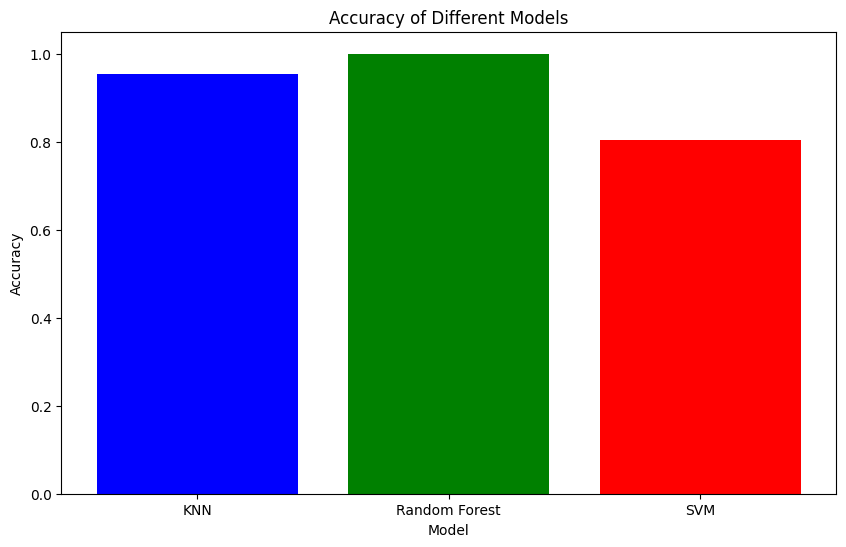

In [8]:
models = {
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

accuracies = {}

for name, model in models.items():
    model.fit(X_train_imputed, y_train)
    predictions = model.predict(X_train_imputed)
    accuracy = accuracy_score(y_train, predictions)
    accuracies[name] = accuracy

# Print the accuracies of each model
print("Model Accuracies:")
for name, accuracy in accuracies.items():
    print(f"{name}: {accuracy}")

# Plot the accuracies
plt.figure(figsize=(10, 6))
plt.bar(accuracies.keys(), accuracies.values(), color=['blue', 'green', 'red'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy of Different Models')
plt.show()